# Notebook 06 — MVP 2: Naive Concatenation Fusion (CLIP image + frozen Run-D text)

**Purpose.** First multimodal MVP. Adds a CLIP ViT-B/16 image branch (LoRA rank 16) on top of the **frozen** Run-D text encoder from MVP 1, fuses by simple feature concatenation, and trains two heads jointly: **T1** (binary hate vs. not) and **T2** (6-class category, masked to `t2_valid=True` rows).

**Why deliberately naive.** Naive concat is the documented MMHS150K failure mode (Gomez 2019 — text-only beats naive multimodal). Establishing it explicitly here lets MVP 4's gated cross-modal fusion claim a real improvement against a measured naive-fusion baseline, not an assumed one.

**Baseline to beat (MVP 1 / Run D, balanced 50/50 test, threshold 0.5):**

| Metric | Value |
|---|---:|
| Test AUC-ROC | 0.7431 |
| Test F1m | 0.6855 |
| Test FPR | 0.2667 |

**Five locked decisions (locked by user spec, do not re-debate):**

1. **Text encoder FROZEN throughout** — no gradient flow through RoBERTa **or** through its LoRA adapter from MVP 1. The MVP 1 head is discarded; the encoder weights (base + LoRA delta) are read-only here.
2. **CLIP backbone frozen** — LoRA rank 16 on the CLIP **vision encoder's** `q_proj` and `v_proj` projections only. PEFT `target_modules=['q_proj','v_proj']` matches by suffix.
3. **T2 loss is masked to `t2_valid=True` rows only.** Invalid rows (`t2_valid=False`, NaN T2) contribute zero to the T2 loss term; the T2 mean is over valid rows only.
4. **Combined loss:** `total = 0.7 * t1_loss + 0.3 * t2_loss_masked_mean`. Weighting is locked.
5. **Naive concatenation only** — `torch.cat([img_768, txt_768], dim=-1) → 1536-d`. No attention, no gating, no MLP-mixer. Cross-modal attention lands in MVP 4 / NB 08.

**Inputs.**
- Frozen text encoder: `models/roberta_mvp1_d/` (Run-D LoRA on `cardiffnlp/twitter-roberta-base-2022-154m`)
- Text tokenizer: `cardiffnlp/twitter-roberta-base-2022-154m` (Hub — matches Run D)
- CLIP model: `openai/clip-vit-base-patch16` (fresh — vision encoder receives a brand-new LoRA r=16)
- Image processor: `CLIPImageProcessor` from `openai/clip-vit-base-patch16` (224×224, ImageNet-style normalisation)
- Labels: `data/processed/labels_parsed.csv` (Phase 1)
- Images: `data/MMHS150K/img_resized/` (Phase 1 audit confirmed all 149,819 GT-referenced images present)
- Official splits: `data/MMHS150K/splits/{train,val,test}_ids.txt` — joined on `tweet_id` to build a `split` column at runtime.

**Outputs.**
- `models/mvp2_naive_concat/` — CLIP LoRA adapter + image projection + T1 head + T2 head + hparams + metrics + training history
- `models/mvp2_naive_concat_best/` — best-by-val-T1-AUC checkpoint during training
- `outputs/nb06_t1_confusion_matrix.png`, `outputs/nb06_t2_confusion_matrix.png`, `outputs/nb06_training_curves.png`

**Architecture (1536-d fused embedding):**

```
input_ids (B, 128) ───► [FROZEN] Twitter-RoBERTa + Run-D LoRA ──► last_hidden_state[:, 0] (B, 768)
                                                                                                  │
pixel_values (B, 3, 224, 224) ─► CLIP vision encoder + LoRA r=16 ──► pooled (B, 768)              │
                                                                          │                       │
                                       [FROZEN] visual_projection (768→512, init from CLIPModel)  │
                                                                          │                       │
                                                               [TRAINABLE] Linear(512→768)         │
                                                                          │                       │
                                                                  img_768 (B, 768)                 │
                                                                          │                       │
                                                                  torch.cat ◄─────────────────────┘
                                                                          │
                                                                fused (B, 1536)
                                                                          │
                                                            ┌─────────────┴───────────────┐
                                                            ▼                             ▼
                                                      T1 head                       T2 head
                                          (Linear 1536→256, ReLU, Dropout 0.1,  (Linear 1536→256, ReLU, Dropout 0.1,
                                           Linear 256→1)                          Linear 256→6)
                                                            │                             │
                                                       logit (B,1)              logits (B,6)
```

**Trainable surface.** CLIP LoRA adapter (~590k params) + frozen-init Linear(512→768) image projection + T1 head + T2 head. Text encoder contributes **zero** trainable params. The frozen 768→512 visual_projection is initialised from `CLIPModel.visual_projection` weights (lifted from the public `openai/clip-vit-base-patch16` checkpoint) so the image embedding entering the trainable Linear(512→768) is the standard CLIP image feature.

In [2]:
import os, sys, json, random, gc, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel,
                          CLIPVisionModel, CLIPModel, CLIPImageProcessor,
                          get_cosine_schedule_with_warmup)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    print(f'gpu mem: {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB')

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=16,
    epochs=5,
    clip_lora_rank=16,
    clip_lora_alpha=32,
    clip_lora_lr=3e-4,
    head_lr=1e-3,
    projection_lr=1e-3,
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    t1_weight=0.7,
    t2_weight=0.3,
    weight_decay=0.01,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter='models/roberta_mvp1_d',
    clip_model='openai/clip-vit-base-patch16',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    n_t2_classes=6,
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
IMG_DIR    = ROOT / 'data' / 'MMHS150K' / 'img_resized'
TEXT_ADAPTER_DIR = ROOT / HPARAMS['text_adapter']
OUT_DIR = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'mvp2_naive_concat'
BEST_DIR  = ROOT / 'models' / 'mvp2_naive_concat_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('LABELS_CSV exists:', LABELS_CSV.exists())
print('SPLITS_DIR exists:', SPLITS_DIR.exists())
print('IMG_DIR    exists:', IMG_DIR.exists())
print('TEXT_ADAPTER_DIR exists:', TEXT_ADAPTER_DIR.exists())

device: cuda | Tesla T4
gpu mem: 14.56 GB
  max_len: 128
  image_size: 224
  batch_size: 16
  epochs: 5
  clip_lora_rank: 16
  clip_lora_alpha: 32
  clip_lora_lr: 0.0003
  head_lr: 0.001
  projection_lr: 0.001
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  t1_weight: 0.7
  t2_weight: 0.3
  weight_decay: 0.01
  text_base: cardiffnlp/twitter-roberta-base-2022-154m
  text_adapter: models/roberta_mvp1_d
  clip_model: openai/clip-vit-base-patch16
  prior_hate: 0.2468
  prior_nothate: 0.7532
  n_t2_classes: 6
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
LABELS_CSV exists: True
SPLITS_DIR exists: True
IMG_DIR    exists: True
TEXT_ADAPTER_DIR exists: True


In [3]:
df = pd.read_csv(LABELS_CSV)
print('raw shape:', df.shape, '| nulls:', df.isna().sum().to_dict())

def read_ids(p):
    return set(int(line.strip()) for line in open(p) if line.strip())

splits = {
    'train': read_ids(SPLITS_DIR / 'train_ids.txt'),
    'val':   read_ids(SPLITS_DIR / 'val_ids.txt'),
    'test':  read_ids(SPLITS_DIR / 'test_ids.txt'),
}
print(f'split txt sizes: train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')

def assign_split(tid):
    for name, s in splits.items():
        if tid in s:
            return name
    return 'unassigned'

df['split'] = df['tweet_id'].map(assign_split)
df = df[df['split'].isin(['train', 'val', 'test'])].reset_index(drop=True)
print('\npost-join shape:', df.shape, '| nulls:', df.isna().sum().to_dict())

T2_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
print('\nper-split T1 + T2 distribution:')
print(f'  {"split":<6} {"n":>7} {"%T1=hate":>9} {"t2_valid":>10} {"t2_NaN":>8}')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    n_t2_valid = int(sub['t2_valid'].sum())
    n_t2_nan = int(sub['T2'].isna().sum())
    print(f'  {s:<6} {len(sub):>7} {sub["T1"].mean()*100:>8.2f}% {n_t2_valid:>10} {n_t2_nan:>8}')
    if n_t2_valid > 0:
        t2_dist = sub.loc[sub['t2_valid'], 'T2'].astype(int).value_counts().sort_index()
        named = {T2_NAMES[i]: int(c) for i, c in t2_dist.items()}
        print(f'         T2 dist (valid only): {named}')

print('\nExpected per Gomez 2019: train ~22% T1=hate, val/test 50% T1-balanced. t2_NaN matches t2_valid=False count by construction.')

raw shape: (149819, 10) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0}
split txt sizes: train=134823 val=5000 test=10000

post-join shape: (149819, 11) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'split': 0}

per-split T1 + T2 distribution:
  split        n  %T1=hate   t2_valid   t2_NaN
  train   134820    21.86%     125501     9319
         T2 dist (valid only): {'NotHate': 105344, 'Racist': 9505, 'Sexist': 2790, 'Homophobe': 3087, 'Religion': 130, 'OtherHate': 4645}
  val       4999    50.01%       4197      802
         T2 dist (valid only): {'NotHate': 2499, 'Racist': 809, 'Sexist': 241, 'Homophobe': 253, 'Religion': 9, 'OtherHate': 386}
  test     10000    50.01%       8411     1589
         T2 dist (valid only): {'NotHate': 4999, 'Racist': 1613, 'Sexist': 464, 'H

In [4]:
print(f'enumerating .jpg files in {IMG_DIR} ...')
_t = time.time()
available_ids = set()
for p in IMG_DIR.iterdir():
    if p.suffix.lower() == '.jpg':
        try:
            available_ids.add(int(p.stem))
        except ValueError:
            continue
print(f'  scandir done in {time.time()-_t:.1f}s, {len(available_ids):,} .jpg files indexed')

before = len(df)
df['img_exists'] = df['tweet_id'].isin(available_ids)
missing_per_split = df[~df['img_exists']].groupby('split').size().to_dict()
print(f'\nrows with no image on disk (per split): {missing_per_split}')
df = df[df['img_exists']].reset_index(drop=True).drop(columns=['img_exists'])
after = len(df)
print(f'dropped {before - after} rows due to missing images. shape: {df.shape}')

print('\nfinal per-split sizes:')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    print(f'  {s:<6} n={len(sub):>7} T1 hate%={sub["T1"].mean()*100:5.2f}% t2_valid={int(sub["t2_valid"].sum())}')
print('nulls after drop:', df.isna().sum().to_dict())

enumerating .jpg files in /teamspace/studios/this_studio/HateFusion/data/MMHS150K/img_resized ...
  scandir done in 0.8s, 150,000 .jpg files indexed

rows with no image on disk (per split): {}
dropped 0 rows due to missing images. shape: (149819, 11)

final per-split sizes:
  train  n= 134820 T1 hate%=21.86% t2_valid=125501
  val    n=   4999 T1 hate%=50.01% t2_valid=4197
  test   n=  10000 T1 hate%=50.01% t2_valid=8411
nulls after drop: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'split': 0}


In [5]:
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'])
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])
print('tokenizer:', tokenizer.__class__.__name__, '| vocab:', tokenizer.vocab_size)
print('image_processor:', image_processor.__class__.__name__, '| size:', image_processor.size)
print('image_processor mean/std:', image_processor.image_mean, '/', image_processor.image_std)

class MMHS150KMultimodalDataset(Dataset):
    """Pre-tokenizes text once. Loads images lazily per __getitem__.
    Hashtags, mentions, URLs preserved verbatim per CLAUDE.md §3.
    T2 NaN rows are stored with placeholder 0 and masked via t2_valid_mask."""

    def __init__(self, sub_df, tok, img_proc, img_dir, max_len):
        texts = sub_df['tweet_text'].astype(str).tolist()
        enc = tok(texts, truncation=True, padding='max_length',
                  max_length=max_len, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.t1_labels = torch.tensor(sub_df['T1'].to_numpy(dtype=np.float32))
        # T2: replace NaN with 0 placeholder; the mask carries the real validity
        t2_arr = sub_df['T2'].fillna(0).to_numpy(dtype=np.int64)
        self.t2_labels = torch.tensor(t2_arr, dtype=torch.long)
        self.t2_valid_mask = torch.tensor(
            sub_df['t2_valid'].to_numpy(dtype=np.bool_), dtype=torch.bool)
        self.tweet_ids = sub_df['tweet_id'].to_numpy(dtype=np.int64)
        self.img_dir = Path(img_dir)
        self.img_proc = img_proc

    def __len__(self):
        return self.t1_labels.size(0)

    def __getitem__(self, idx):
        tid = int(self.tweet_ids[idx])
        with Image.open(self.img_dir / f'{tid}.jpg') as im:
            if im.mode != 'RGB':
                im = im.convert('RGB')
            pixel = self.img_proc(im, return_tensors='pt')['pixel_values'].squeeze(0)
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'pixel_values': pixel,
            't1_label': self.t1_labels[idx],
            't2_label': self.t2_labels[idx],
            't2_valid_mask': self.t2_valid_mask[idx],
            'tweet_id': tid,
        }

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'\nsplit frames: train {train_df.shape} | val {val_df.shape} | test {test_df.shape}')

print('tokenising text (one pass per split)...')
_t = time.time()
train_ds = MMHS150KMultimodalDataset(train_df, tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'])
val_ds   = MMHS150KMultimodalDataset(val_df,   tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'])
test_ds  = MMHS150KMultimodalDataset(test_df,  tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'])
print(f'  done in {time.time()-_t:.1f}s')
print(f'datasets: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)

# sanity-check one batch's shapes (cheap, no GPU)
_b = train_ds[0]
print(f'sample shapes: input_ids {tuple(_b["input_ids"].shape)}, '
      f'pixel_values {tuple(_b["pixel_values"].shape)}, t1 {_b["t1_label"].item()}, '
      f't2 {_b["t2_label"].item()}, t2_valid {bool(_b["t2_valid_mask"].item())}')

tokenizer: RobertaTokenizer | vocab: 50265
image_processor: CLIPImageProcessor | size: SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None)
image_processor mean/std: (0.48145466, 0.4578275, 0.40821073) / (0.26862954, 0.26130258, 0.27577711)

split frames: train (134820, 11) | val (4999, 11) | test (10000, 11)
tokenising text (one pass per split)...
  done in 31.6s
datasets: train 134820 | val 4999 | test 10000
sample shapes: input_ids (128,), pixel_values (3, 224, 224), t1 1.0, t2 0, t2_valid False


In [6]:
# --- T1: Focal BCE with pos_weight from train T1 distribution ----------------
y_train_t1 = train_df['T1'].to_numpy()
cw_t1 = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_t1)
pos_weight_value = float(cw_t1[1] / cw_t1[0])
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'T1 class weights from TRAIN: nothate={cw_t1[0]:.4f}, hate={cw_t1[1]:.4f}')
print(f'T1 pos_weight (hate/nothate ratio): {pos_weight_value:.4f}')

class FocalBCE(nn.Module):
    """Binary focal cross-entropy with positive-class weighting (matches Run D's loss)."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
    def forward(self, logits, target):
        logits = logits.view(-1)
        target = target.view(-1).float()
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        p = torch.sigmoid(logits)
        pt = p * target + (1.0 - p) * (1.0 - target)
        focal = (1.0 - pt).pow(self.gamma) * bce
        if self.pos_weight is not None:
            w = target * self.pos_weight + (1.0 - target)
            focal = focal * w
        return focal.mean()

criterion_t1 = FocalBCE(gamma=HPARAMS['gamma'], pos_weight=pos_weight)
print(f'criterion_t1: FocalBCE(gamma={HPARAMS["gamma"]}, pos_weight={pos_weight_value:.4f})')

# --- T2: masked Focal CE with class weights from train t2_valid=True rows ---
y_train_t2_valid = train_df.loc[train_df['t2_valid'], 'T2'].astype(int).to_numpy()
cw_t2_np = compute_class_weight('balanced',
                                 classes=np.arange(HPARAMS['n_t2_classes']),
                                 y=y_train_t2_valid)
cw_t2 = torch.tensor(cw_t2_np, dtype=torch.float32, device=device)
print(f'\nT2 class weights from TRAIN (t2_valid=True only):')
for i, w in enumerate(cw_t2_np):
    n_i = int((y_train_t2_valid == i).sum())
    print(f'  {T2_NAMES[i]:>10s}  weight={w:.4f}  train_count={n_i}')

class MaskedFocalCE(nn.Module):
    """Multi-class focal CE with per-class weighting AND a per-sample boolean mask.
    Per-sample losses are zeroed for masked-out rows; the returned mean is over
    valid rows only. If no valid rows in batch, returns 0 with grad."""
    def __init__(self, gamma=2.0, weight=None, num_classes=6):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.num_classes = num_classes
    def forward(self, logits, target, mask):
        # logits: (B, C), target: (B,) long (placeholder 0 on masked-out rows), mask: (B,) bool
        logp = F.log_softmax(logits, dim=-1)
        p = logp.exp()
        idx = target.unsqueeze(1).clamp_(min=0, max=self.num_classes - 1)
        t_logp = logp.gather(1, idx).squeeze(1)
        t_p = p.gather(1, idx).squeeze(1)
        focal = (1.0 - t_p).pow(self.gamma) * (-t_logp)
        if self.weight is not None:
            w = self.weight.gather(0, target.clamp(min=0, max=self.num_classes - 1))
            focal = focal * w
        m = mask.float()
        n_valid = m.sum()
        if n_valid.item() == 0:
            # zero with grad — multiply logits by 0 so autograd has a path; identical to .sum()*0
            return logits.sum() * 0.0
        return (focal * m).sum() / n_valid

criterion_t2 = MaskedFocalCE(gamma=HPARAMS['gamma'], weight=cw_t2,
                              num_classes=HPARAMS['n_t2_classes'])
print(f'\ncriterion_t2: MaskedFocalCE(gamma={HPARAMS["gamma"]}, weight=<train-balanced>)')
print(f'combined loss = {HPARAMS["t1_weight"]} * t1_loss + {HPARAMS["t2_weight"]} * t2_loss_masked_mean')

T1 class weights from TRAIN: nothate=0.6399, hate=2.2869
T1 pos_weight (hate/nothate ratio): 3.5739
criterion_t1: FocalBCE(gamma=2.0, pos_weight=3.5739)

T2 class weights from TRAIN (t2_valid=True only):
     NotHate  weight=0.1986  train_count=105344
      Racist  weight=2.2006  train_count=9505
      Sexist  weight=7.4971  train_count=2790
   Homophobe  weight=6.7758  train_count=3087
    Religion  weight=160.8987  train_count=130
   OtherHate  weight=4.5031  train_count=4645

criterion_t2: MaskedFocalCE(gamma=2.0, weight=<train-balanced>)
combined loss = 0.7 * t1_loss + 0.3 * t2_loss_masked_mean


In [7]:
class MVP2NaiveConcat(nn.Module):
    """Frozen Run-D text encoder + LoRA-tunable CLIP vision + naive concat fusion + dual heads."""

    def __init__(self, text_base: str, text_adapter_dir: str,
                 clip_model_name: str, clip_lora_rank: int, clip_lora_alpha: int,
                 n_t2_classes: int = 6, dropout: float = 0.1):
        super().__init__()

        # --- TEXT BRANCH (frozen) -------------------------------------------
        base_text = AutoModel.from_pretrained(text_base)
        self.text_encoder = PeftModel.from_pretrained(
            base_text, text_adapter_dir, is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        # --- IMAGE BRANCH (CLIP vision + LoRA) ------------------------------
        # We use CLIPVisionModel for the encoder (85M params) and lift the
        # frozen visual_projection (768→512) from the public CLIPModel checkpoint
        # so the 512-d feature entering our trainable Linear(512→768) is the
        # canonical CLIP image embedding.
        clip_full = CLIPModel.from_pretrained(clip_model_name)
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full
        gc.collect()

        vision_tower = CLIPVisionModel.from_pretrained(clip_model_name)
        clip_lora_cfg = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=clip_lora_rank,
            lora_alpha=clip_lora_alpha,
            lora_dropout=0.1,
            target_modules=['q_proj', 'v_proj'],
            bias='none',
        )
        self.vision_encoder = get_peft_model(vision_tower, clip_lora_cfg)
        # CLIPVisionModel hidden_size is 768 (CLIP-base)
        clip_hidden = vision_tower.config.hidden_size

        # Frozen 768→512 (the canonical CLIP visual_projection)
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False

        # Trainable 512→768 (cross-modal dim alignment — CLAUDE.md §3 / user spec)
        self.image_projection = nn.Linear(512, 768)

        # --- FUSION HEADS ---------------------------------------------------
        fused_dim = 768 + 768  # 1536
        hidden = 256
        self.head_t1 = nn.Sequential(
            nn.Linear(fused_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
        self.head_t2 = nn.Sequential(
            nn.Linear(fused_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_t2_classes),
        )

    def encode_text(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0]   # (B, 768)

    def encode_image(self, pixel_values):
        # IMPORTANT — PEFT 0.19's PeftModel.forward has a kwarg-collision bug with
        # transformers 5.x's CLIPVisionModel (CLIPEncoder receives `inputs_embeds`
        # twice). Bypass the outer PeftModel.forward by calling the inner
        # base_model.model directly. The LoRA adapter modules live deep in the
        # encoder's attention projections so they still apply on this path.
        out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
        pooled = out.pooler_output           # (B, 768)
        feat_512 = self.visual_projection_to_512(pooled)  # frozen 768→512
        return self.image_projection(feat_512)            # trainable 512→768

    def forward(self, input_ids, attention_mask, pixel_values):
        txt = self.encode_text(input_ids, attention_mask)     # (B, 768)
        img = self.encode_image(pixel_values)                 # (B, 768)
        fused = torch.cat([img, txt], dim=-1)                 # (B, 1536)
        return self.head_t1(fused), self.head_t2(fused)


model = MVP2NaiveConcat(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    clip_lora_rank=HPARAMS['clip_lora_rank'],
    clip_lora_alpha=HPARAMS['clip_lora_alpha'],
    n_t2_classes=HPARAMS['n_t2_classes'],
).to(device)

# Trainable-surface audit
def count_params(named_iter, predicate):
    return sum(p.numel() for n, p in named_iter if predicate(n, p))

named = list(model.named_parameters())
total_params = sum(p.numel() for _, p in named)
trainable_total = sum(p.numel() for _, p in named if p.requires_grad)
text_trainable = count_params(named, lambda n, p: n.startswith('text_encoder.') and p.requires_grad)
vision_lora_trainable = count_params(named, lambda n, p: n.startswith('vision_encoder.') and 'lora_' in n and p.requires_grad)
vis_proj_512_trainable = count_params(named, lambda n, p: n.startswith('visual_projection_to_512.') and p.requires_grad)
img_proj_trainable = count_params(named, lambda n, p: n.startswith('image_projection.') and p.requires_grad)
head_t1_trainable = count_params(named, lambda n, p: n.startswith('head_t1.') and p.requires_grad)
head_t2_trainable = count_params(named, lambda n, p: n.startswith('head_t2.') and p.requires_grad)

print(f'total params:                          {total_params:>15,}')
print(f'trainable total:                       {trainable_total:>15,}  ({100*trainable_total/total_params:.3f}%)')
print(f'  text encoder trainable:              {text_trainable:>15,}  (must be 0)')
print(f'  CLIP vision LoRA trainable:          {vision_lora_trainable:>15,}')
print(f'  frozen visual_projection (768->512): {vis_proj_512_trainable:>15,}  (must be 0)')
print(f'  image_projection (512->768):         {img_proj_trainable:>15,}')
print(f'  head_t1:                             {head_t1_trainable:>15,}')
print(f'  head_t2:                             {head_t2_trainable:>15,}')

assert text_trainable == 0, 'TEXT ENCODER NOT FROZEN — violation of locked decision #1'
assert vis_proj_512_trainable == 0, 'frozen visual_projection_to_512 has trainable params — bug'
assert vision_lora_trainable > 0, 'CLIP LoRA adapter is frozen — violation of locked decision #2'
print('\nLocked decisions #1 (text frozen) and #2 (CLIP LoRA trainable) verified.')
model.vision_encoder.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.embeddings.position_embedding.w

total params:                              213,790,471
trainable total:                             1,772,551  (0.829%)
  text encoder trainable:                            0  (must be 0)
  CLIP vision LoRA trainable:                  589,824
  frozen visual_projection (768->512):               0  (must be 0)
  image_projection (512->768):                 393,984
  head_t1:                                     393,729
  head_t2:                                     395,014

Locked decisions #1 (text frozen) and #2 (CLIP LoRA trainable) verified.
trainable params: 589,824 || all params: 86,389,248 || trainable%: 0.6828


In [8]:
clip_lora_params  = [p for n, p in model.named_parameters() if n.startswith('vision_encoder.') and 'lora_' in n and p.requires_grad]
img_proj_params   = [p for n, p in model.named_parameters() if n.startswith('image_projection.') and p.requires_grad]
head_params       = [p for n, p in model.named_parameters() if (n.startswith('head_t1.') or n.startswith('head_t2.')) and p.requires_grad]

# Defensive: every remaining trainable param must be in exactly one of the groups above
covered = {id(p) for p in clip_lora_params + img_proj_params + head_params}
stragglers = [n for n, p in model.named_parameters() if p.requires_grad and id(p) not in covered]
assert not stragglers, f'trainable params not assigned to an optimiser group: {stragglers[:5]}'

optimizer = torch.optim.AdamW(
    [
        {'params': clip_lora_params, 'lr': HPARAMS['clip_lora_lr']},
        {'params': img_proj_params,  'lr': HPARAMS['projection_lr']},
        {'params': head_params,      'lr': HPARAMS['head_lr']},
    ],
    weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
opt_steps_per_epoch  = data_steps_per_epoch // HPARAMS['grad_accum_steps']
total_opt_steps      = opt_steps_per_epoch * HPARAMS['epochs']
warmup_steps         = int(HPARAMS['warmup_ratio'] * total_opt_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps,
)
print(f'data steps/epoch: {data_steps_per_epoch}')
print(f'opt  steps/epoch: {opt_steps_per_epoch}  (grad_accum={HPARAMS["grad_accum_steps"]}, effective batch={HPARAMS["batch_size"]*HPARAMS["grad_accum_steps"]})')
print(f'total opt steps:  {total_opt_steps}  |  warmup: {warmup_steps}')
print(f'param groups: clip_lora lr={HPARAMS["clip_lora_lr"]} ({len(clip_lora_params)}) | img_proj lr={HPARAMS["projection_lr"]} ({len(img_proj_params)}) | heads lr={HPARAMS["head_lr"]} ({len(head_params)})')

data steps/epoch: 8427
opt  steps/epoch: 2106  (grad_accum=4, effective batch=64)
total opt steps:  10530  |  warmup: 1053
param groups: clip_lora lr=0.0003 (48) | img_proj lr=0.001 (2) | heads lr=0.001 (8)


In [9]:
scaler = torch.amp.GradScaler('cuda')
history = {
    'epoch': [], 'train_total': [], 'train_t1': [], 'train_t2': [],
    'val_total': [], 'val_t1_loss': [], 'val_t2_loss': [],
    'val_t1_auc': [], 'val_t1_f1': [], 'val_t2_macro_f1': [],
}
best_t1_auc, best_epoch = -1.0, -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    model.text_encoder.eval()   # keep frozen text encoder in eval mode (no dropout)
    t0 = time.time()
    run_tot, run_t1, run_t2, n_batches = 0.0, 0.0, 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(device, non_blocking=True)
        mask  = batch['attention_mask'].to(device, non_blocking=True)
        pix   = batch['pixel_values'].to(device, non_blocking=True)
        y1    = batch['t1_label'].to(device, non_blocking=True)
        y2    = batch['t2_label'].to(device, non_blocking=True)
        m2    = batch['t2_valid_mask'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logit_t1, logits_t2 = model(ids, mask, pix)
            l_t1 = criterion_t1(logit_t1, y1)
            l_t2 = criterion_t2(logits_t2, y2, m2)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2
            scaled_loss = loss / HPARAMS['grad_accum_steps']
        scaler.scale(scaled_loss).backward()
        run_tot += loss.item(); run_t1 += l_t1.item(); run_t2 += l_t2.item(); n_batches += 1
        if (step + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
    train_total = run_tot / max(n_batches, 1)
    train_t1    = run_t1  / max(n_batches, 1)
    train_t2    = run_t2  / max(n_batches, 1)

    # Validation
    model.eval()
    val_tot, val_t1l, val_t2l, nb = 0.0, 0.0, 0.0, 0
    v_t1_probs, v_t1_true, v_t2_preds, v_t2_true, v_t2_valid = [], [], [], [], []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids  = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            pix  = batch['pixel_values'].to(device, non_blocking=True)
            y1   = batch['t1_label'].to(device, non_blocking=True)
            y2   = batch['t2_label'].to(device, non_blocking=True)
            m2   = batch['t2_valid_mask'].to(device, non_blocking=True)
            logit_t1, logits_t2 = model(ids, mask, pix)
            l_t1 = criterion_t1(logit_t1, y1)
            l_t2 = criterion_t2(logits_t2, y2, m2)
            val_tot += (HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2).item()
            val_t1l += l_t1.item(); val_t2l += l_t2.item(); nb += 1
            v_t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
            v_t1_true.append(y1.cpu().numpy())
            v_t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
            v_t2_true.append(y2.cpu().numpy())
            v_t2_valid.append(m2.cpu().numpy())
    val_total = val_tot / max(nb, 1); val_t1_loss = val_t1l / max(nb, 1); val_t2_loss = val_t2l / max(nb, 1)
    v_t1_probs = np.concatenate(v_t1_probs); v_t1_true = np.concatenate(v_t1_true)
    v_t2_preds = np.concatenate(v_t2_preds); v_t2_true = np.concatenate(v_t2_true); v_t2_valid = np.concatenate(v_t2_valid)
    val_t1_auc = roc_auc_score(v_t1_true, v_t1_probs)
    val_t1_f1  = f1_score(v_t1_true, (v_t1_probs >= HPARAMS['threshold']).astype(int))
    if v_t2_valid.sum() > 0:
        val_t2_macro_f1 = f1_score(v_t2_true[v_t2_valid], v_t2_preds[v_t2_valid], average='macro', labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    else:
        val_t2_macro_f1 = float('nan')

    elapsed = time.time() - t0
    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train tot={train_total:.4f} t1={train_t1:.4f} t2={train_t2:.4f}  |  '
          f'val tot={val_total:.4f} t1={val_t1_loss:.4f} t2={val_t2_loss:.4f}  |  '
          f'val_t1_auc={val_t1_auc:.4f}  val_t1_f1={val_t1_f1:.4f}  val_t2_macro_f1={val_t2_macro_f1:.4f}  ({elapsed:.1f}s)')

    for k, v in [('epoch', epoch), ('train_total', train_total), ('train_t1', train_t1), ('train_t2', train_t2),
                 ('val_total', val_total), ('val_t1_loss', val_t1_loss), ('val_t2_loss', val_t2_loss),
                 ('val_t1_auc', val_t1_auc), ('val_t1_f1', val_t1_f1), ('val_t2_macro_f1', val_t2_macro_f1)]:
        history[k].append(v)

    if val_t1_auc > best_t1_auc:
        best_t1_auc = val_t1_auc; best_epoch = epoch
        # Save the CLIP LoRA adapter (peft) + everything else as a single state_dict
        model.vision_encoder.save_pretrained(BEST_DIR)
        torch.save({
            'image_projection': model.image_projection.state_dict(),
            'head_t1': model.head_t1.state_dict(),
            'head_t2': model.head_t2.state_dict(),
            'epoch': epoch,
            'val_t1_auc': val_t1_auc,
            'val_t2_macro_f1': float(val_t2_macro_f1),
        }, BEST_DIR / 'rest.pt')
        print(f'  -> new best val_t1_auc={val_t1_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_t1_auc: {best_t1_auc:.4f}')

[epoch 1/5] train tot=0.4002 t1=0.2329 t2=0.7908  |  val tot=0.5776 t1=0.3381 t2=1.1366  |  val_t1_auc=0.7488  val_t1_f1=0.6939  val_t2_macro_f1=0.3763  (1401.1s)
  -> new best val_t1_auc=0.7488, saved to /teamspace/studios/this_studio/HateFusion/models/mvp2_naive_concat_best
[epoch 2/5] train tot=0.3159 t1=0.2291 t2=0.5185  |  val tot=0.5513 t1=0.3360 t2=1.0538  |  val_t1_auc=0.7484  val_t1_f1=0.7018  val_t2_macro_f1=0.5043  (1397.2s)
[epoch 3/5] train tot=0.2996 t1=0.2286 t2=0.4651  |  val tot=0.5574 t1=0.3597 t2=1.0188  |  val_t1_auc=0.7479  val_t1_f1=0.6904  val_t2_macro_f1=0.5062  (1397.0s)
[epoch 4/5] train tot=0.2885 t1=0.2280 t2=0.4298  |  val tot=0.5496 t1=0.3532 t2=1.0079  |  val_t1_auc=0.7476  val_t1_f1=0.6845  val_t2_macro_f1=0.4869  (1397.9s)
[epoch 5/5] train tot=0.2802 t1=0.2275 t2=0.4033  |  val tot=0.5523 t1=0.3506 t2=1.0228  |  val_t1_auc=0.7484  val_t1_f1=0.6889  val_t2_macro_f1=0.4976  (1402.4s)

best epoch: 1 | best val_t1_auc: 0.7488


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.embeddings.position_embedding.w

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.embeddings.position_embedding.w

reloaded best (epoch 1, val_t1_auc=0.7488)

TEST T1 (balanced 50/50, threshold 0.5):
  AUC-ROC       : 0.7411
  F1   (macro)  : 0.6892
  Precision (M) : 0.6892
  Recall    (M) : 0.6892
  CM            : TN=3479 FP=1520 FN=1588 TP=3413
  FPR           : 0.3041

TEST T2 (t2_valid=True only, n=8411 / 10000):
  macro F1: 0.3795
              precision    recall  f1-score   support

     NotHate     0.9167    0.0462    0.0880      4999
      Racist     0.3021    0.8345    0.4436      1613
      Sexist     0.2965    0.5668    0.3893       464
   Homophobe     0.6237    0.7928    0.6982       531
    Religion     0.0134    0.7500    0.0263        24
   OtherHate     0.6259    0.6372    0.6315       780

    accuracy                         0.3300      8411
   macro avg     0.4630    0.6046    0.3795      8411
weighted avg     0.7166    0.3300    0.2615      8411



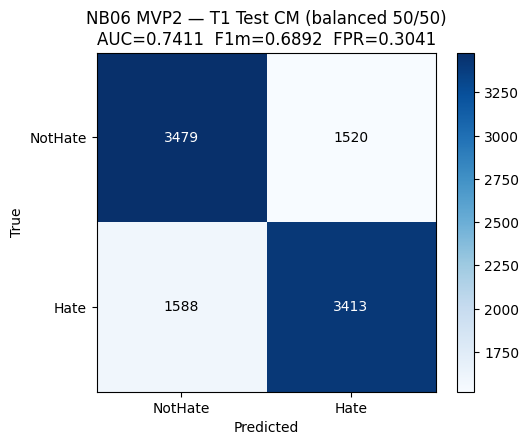

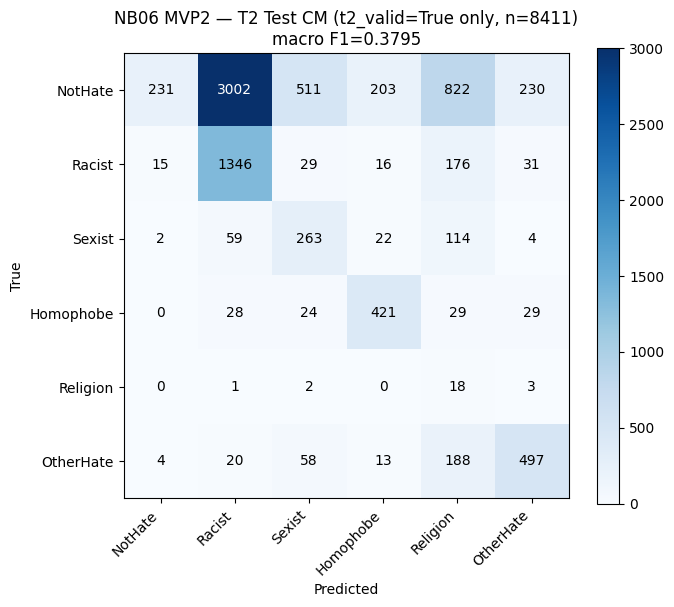

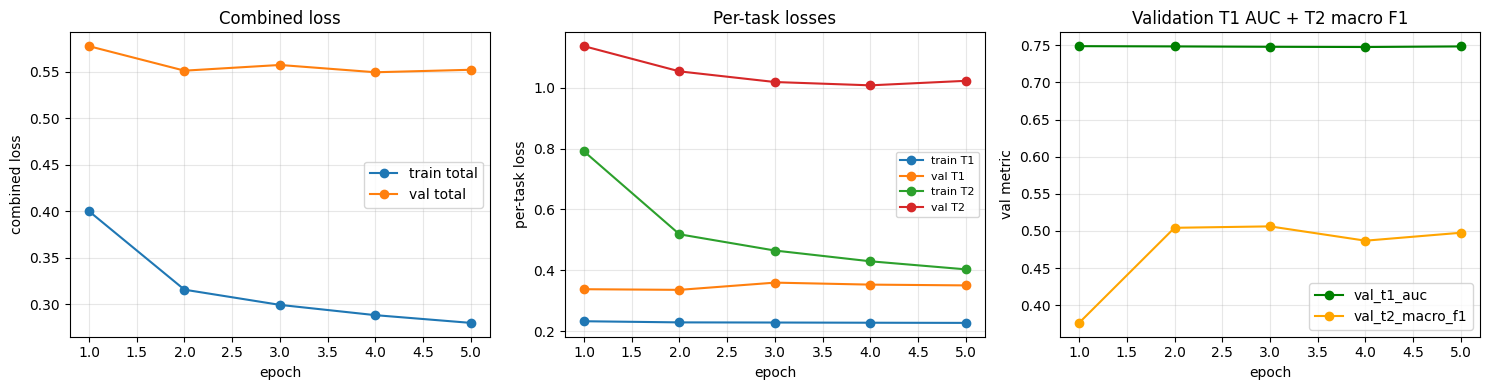

In [10]:
del model
gc.collect(); torch.cuda.empty_cache()

# Reload from best checkpoint
best_model = MVP2NaiveConcat(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    clip_lora_rank=HPARAMS['clip_lora_rank'],
    clip_lora_alpha=HPARAMS['clip_lora_alpha'],
    n_t2_classes=HPARAMS['n_t2_classes'],
).to(device)
# Swap in saved LoRA adapter for the vision branch
best_vision_base = CLIPVisionModel.from_pretrained(HPARAMS['clip_model'])
best_model.vision_encoder = PeftModel.from_pretrained(best_vision_base, str(BEST_DIR), is_trainable=False).to(device)
# Reload the rest
rest = torch.load(BEST_DIR / 'rest.pt', map_location='cpu', weights_only=False)
best_model.image_projection.load_state_dict(rest['image_projection'])
best_model.head_t1.load_state_dict(rest['head_t1'])
best_model.head_t2.load_state_dict(rest['head_t2'])
best_model.to(device).eval()
print(f'reloaded best (epoch {rest["epoch"]}, val_t1_auc={rest["val_t1_auc"]:.4f})')

# Test-set forward pass
t1_probs, t1_true, t2_preds, t2_true, t2_valid = [], [], [], [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        logit_t1, logits_t2 = best_model(ids, mask, pix)
        t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        t1_true.append(batch['t1_label'].cpu().numpy())
        t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
        t2_true.append(batch['t2_label'].cpu().numpy())
        t2_valid.append(batch['t2_valid_mask'].cpu().numpy())
all_t1_probs = np.concatenate(t1_probs); all_t1_true = np.concatenate(t1_true)
all_t2_preds = np.concatenate(t2_preds); all_t2_true = np.concatenate(t2_true); all_t2_valid = np.concatenate(t2_valid)

# --- T1 metrics ---
t1_pred = (all_t1_probs >= HPARAMS['threshold']).astype(int)
t1_auc  = roc_auc_score(all_t1_true, all_t1_probs)
t1_f1m  = f1_score(all_t1_true, t1_pred, average='macro')
t1_pm   = precision_score(all_t1_true, t1_pred, average='macro', zero_division=0)
t1_rm   = recall_score(all_t1_true, t1_pred, average='macro', zero_division=0)
cm_t1   = confusion_matrix(all_t1_true, t1_pred, labels=[0, 1])
tn, fp, fn, tp = cm_t1.ravel()
t1_fpr  = fp / max(fp + tn, 1)
print(f'\nTEST T1 (balanced 50/50, threshold {HPARAMS["threshold"]}):')
print(f'  AUC-ROC       : {t1_auc:.4f}')
print(f'  F1   (macro)  : {t1_f1m:.4f}')
print(f'  Precision (M) : {t1_pm:.4f}')
print(f'  Recall    (M) : {t1_rm:.4f}')
print(f'  CM            : TN={tn} FP={fp} FN={fn} TP={tp}')
print(f'  FPR           : {t1_fpr:.4f}')

# --- T2 metrics (valid rows only) ---
mask_v = all_t2_valid.astype(bool)
n_valid_test = int(mask_v.sum())
print(f'\nTEST T2 (t2_valid=True only, n={n_valid_test} / {len(all_t2_valid)}):')
if n_valid_test > 0:
    t2_f1m_macro = f1_score(all_t2_true[mask_v], all_t2_preds[mask_v], average='macro',
                            labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    print(f'  macro F1: {t2_f1m_macro:.4f}')
    print(classification_report(all_t2_true[mask_v], all_t2_preds[mask_v],
                                labels=list(range(HPARAMS['n_t2_classes'])),
                                target_names=T2_NAMES, digits=4, zero_division=0))
    cm_t2 = confusion_matrix(all_t2_true[mask_v], all_t2_preds[mask_v],
                             labels=list(range(HPARAMS['n_t2_classes'])))
else:
    t2_f1m_macro = float('nan')
    cm_t2 = np.zeros((HPARAMS['n_t2_classes'], HPARAMS['n_t2_classes']), dtype=int)

# --- Plots ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm_t1, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB06 MVP2 — T1 Test CM (balanced 50/50)\nAUC={t1_auc:.4f}  F1m={t1_f1m:.4f}  FPR={t1_fpr:.4f}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm_t1[i, j]), ha='center', va='center',
                color='white' if cm_t1[i, j] > cm_t1.max() / 2 else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'nb06_t1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_t2, cmap='Blues')
ax.set_xticks(range(HPARAMS['n_t2_classes'])); ax.set_yticks(range(HPARAMS['n_t2_classes']))
ax.set_xticklabels(T2_NAMES, rotation=45, ha='right'); ax.set_yticklabels(T2_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB06 MVP2 — T2 Test CM (t2_valid=True only, n={n_valid_test})\nmacro F1={t2_f1m_macro:.4f}')
thresh = cm_t2.max() / 2 if cm_t2.max() > 0 else 1
for i in range(HPARAMS['n_t2_classes']):
    for j in range(HPARAMS['n_t2_classes']):
        ax.text(j, i, int(cm_t2[i, j]), ha='center', va='center',
                color='white' if cm_t2[i, j] > thresh else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'nb06_t2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['epoch'], history['train_total'], '-o', label='train total')
axes[0].plot(history['epoch'], history['val_total'],   '-o', label='val total')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('combined loss'); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Combined loss')
axes[1].plot(history['epoch'], history['train_t1'], '-o', label='train T1')
axes[1].plot(history['epoch'], history['val_t1_loss'], '-o', label='val T1')
axes[1].plot(history['epoch'], history['train_t2'], '-o', label='train T2')
axes[1].plot(history['epoch'], history['val_t2_loss'], '-o', label='val T2')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('per-task loss'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_title('Per-task losses')
axes[2].plot(history['epoch'], history['val_t1_auc'], '-o', color='green', label='val_t1_auc')
axes[2].plot(history['epoch'], history['val_t2_macro_f1'], '-o', color='orange', label='val_t2_macro_f1')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('val metric'); axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_title('Validation T1 AUC + T2 macro F1')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb06_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
prior_hate = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

# Compute val T1 probs again with the loaded best model (for the threshold search)
v_probs, v_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        logit_t1, _ = best_model(ids, mask, pix)
        v_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        v_true.append(batch['t1_label'].cpu().numpy())
val_probs_arr = np.concatenate(v_probs); val_true_arr = np.concatenate(v_true)

test_probs_recal = recalibrate(all_t1_probs)
val_probs_recal  = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    pred = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, pred)
    if fv > best_thr_f1:
        best_thr_f1 = fv; best_thr = float(t)
print(f'F1-optimised threshold on RECALIBRATED VAL: {best_thr:.3f} (val F1={best_thr_f1:.4f})')
print(f'  recalibrated val prob range: [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}], mean={val_probs_recal.mean():.4f}')
print(f'  recalibrated test prob range: [{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}], mean={test_probs_recal.mean():.4f}')

def metrics_at(true_labels, probs, thr):
    pred = (probs >= thr).astype(int)
    auc_ = roc_auc_score(true_labels, probs)
    f1m_ = f1_score(true_labels, pred, average='macro')
    pm_  = precision_score(true_labels, pred, average='macro', zero_division=0)
    rm_  = recall_score(true_labels, pred, average='macro', zero_division=0)
    cm_  = confusion_matrix(true_labels, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm_.ravel()
    fpr_ = fp_ / max(fp_ + tn_, 1)
    return dict(AUC=auc_, F1m=f1m_, Pm=pm_, Rm=rm_, FPR=fpr_,
                TN=int(tn_), FP=int(fp_), FN=int(fn_), TP=int(tp_))

m_bal = metrics_at(all_t1_true, all_t1_probs, 0.5)
m_rec = metrics_at(all_t1_true, test_probs_recal, best_thr)

print('\n=== T1 SIDE-BY-SIDE METRICS ===')
print(f'  balanced   (50/50 test, threshold = 0.5)')
print(f'  recalibrated (P(hate)={prior_hate}, threshold = {best_thr:.3f}, F1-opt on recal val)\n')
print(f'  {"metric":<14}  {"balanced (50/50, thr=0.5)":<28}  {"recalibrated (~22% hate, thr=F1-opt)":<40}')
for key, name in [('AUC', 'AUC-ROC'), ('F1m', 'F1 (macro)'),
                  ('Pm', 'Precision (M)'), ('Rm', 'Recall (M)'), ('FPR', 'FPR')]:
    print(f'  {name:<14}  {m_bal[key]:<28.4f}  {m_rec[key]:<40.4f}')
print(f'  CM balanced     TN={m_bal["TN"]:5} FP={m_bal["FP"]:5} FN={m_bal["FN"]:5} TP={m_bal["TP"]:5}')
print(f'  CM recalibrated TN={m_rec["TN"]:5} FP={m_rec["FP"]:5} FN={m_rec["FN"]:5} TP={m_rec["TP"]:5}')

metrics_summary = {
    'run_label': 'mvp2_naive_concat',
    'best_epoch': int(rest['epoch']),
    'best_val_t1_auc': float(rest['val_t1_auc']),
    'best_val_t2_macro_f1': float(rest['val_t2_macro_f1']),
    't1_pos_weight': pos_weight_value,
    't1_thresholds': {
        'balanced_headline': 0.5,
        'recal_f1_optimised_on_recal_val': best_thr,
    },
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    't1_balanced_test_thr_0.5':     {k: float(v) if not isinstance(v, int) else v for k, v in m_bal.items()},
    't1_recalibrated_test_thr_opt': {k: float(v) if not isinstance(v, int) else v for k, v in m_rec.items()},
    't2_test_macro_f1_valid_only':  float(t2_f1m_macro),
    't2_test_n_valid':              n_valid_test,
    'loss_weights': {'t1': HPARAMS['t1_weight'], 't2': HPARAMS['t2_weight']},
}
print('\nmetrics_summary keys:', list(metrics_summary.keys()))

F1-optimised threshold on RECALIBRATED VAL: 0.220 (val F1=0.7139)
  recalibrated val prob range: [0.0452, 0.5126], mean=0.2649
  recalibrated test prob range: [0.0424, 0.5274], mean=0.2665

=== T1 SIDE-BY-SIDE METRICS ===
  balanced   (50/50 test, threshold = 0.5)
  recalibrated (P(hate)=0.2468, threshold = 0.220, F1-opt on recal val)

  metric          balanced (50/50, thr=0.5)     recalibrated (~22% hate, thr=F1-opt)    
  AUC-ROC         0.7411                        0.7411                                  
  F1 (macro)      0.6892                        0.6828                                  
  Precision (M)   0.6892                        0.6879                                  
  Recall (M)      0.6892                        0.6843                                  
  FPR             0.3041                        0.3851                                  
  CM balanced     TN= 3479 FP= 1520 FN= 1588 TP= 3413
  CM recalibrated TN= 3074 FP= 1925 FN= 1232 TP= 3769

metrics_summary key

In [12]:
# --- Final comparison vs MVP 1 baseline (Run D) -----------------------------
mvp1_auc, mvp1_f1m, mvp1_fpr = 0.7431, 0.6855, 0.2667
this_auc = m_bal['AUC']; this_f1m = m_bal['F1m']; this_fpr = m_bal['FPR']
d_auc = this_auc - mvp1_auc
d_f1m = this_f1m - mvp1_f1m
d_fpr = this_fpr - mvp1_fpr

print('=== MVP 1 (Run D, text-only) vs MVP 2 (this run, naive concat) ===')
print(f'  {"":<28} {"MVP 1 (Run D)":<15} {"MVP 2 (naive)":<15} {"Δ":<10}')
print(f'  {"Test AUC-ROC":<28} {mvp1_auc:<15.4f} {this_auc:<15.4f} {d_auc:+.4f}')
print(f'  {"Test F1 (macro)":<28} {mvp1_f1m:<15.4f} {this_f1m:<15.4f} {d_f1m:+.4f}')
print(f'  {"Test FPR":<28} {mvp1_fpr:<15.4f} {this_fpr:<15.4f} {d_fpr:+.4f}')

# Verdict
NOISE = 0.02  # ±0.02 AUC band from §11.4 of Phase2 report
if d_auc >= NOISE:
    verdict_label = 'NAIVE CONCAT BEATS TEXT-ONLY (unexpected — flag for review)'
    verdict_detail = (
        'Test AUC of naive concat is more than +0.02 above MVP 1. This contradicts the documented '
        'Gomez 2019 failure mode. Inspect for data leakage, evaluation bug, or genuinely informative image branch.')
elif d_auc <= -NOISE:
    verdict_label = 'NAIVE CONCAT UNDERPERFORMS TEXT-ONLY (Gomez 2019 failure mode confirmed)'
    verdict_detail = (
        'Test AUC drops by more than 0.02 vs MVP 1. This is the documented MMHS150K failure mode for naive multimodal '
        'fusion — image branch is adding noise rather than complementary signal. This is the load-bearing observation '
        'that motivates the gated fusion in MVP 4 (NB 08).')
else:
    verdict_label = 'NAIVE CONCAT ≈ TEXT-ONLY (within ±0.02 AUC noise band)'
    verdict_detail = (
        'Test AUC of naive concat is within ±0.02 of MVP 1. Image branch is not load-bearing under naive concatenation. '
        'This still motivates gated fusion (MVP 4) — if a better fusion mechanism exists, it must be measured against '
        'this naive-concat number as well as MVP 1.')
print(f'\n=== VERDICT: {verdict_label} ===')
print(verdict_detail)

# --- Save final model -------------------------------------------------------
if MODEL_DIR.exists() and any(MODEL_DIR.iterdir()):
    for p in list(MODEL_DIR.iterdir()):
        if p.is_file():
            p.unlink()
        elif p.is_dir():
            shutil.rmtree(p)

for src in BEST_DIR.iterdir():
    dst = MODEL_DIR / src.name
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump(HPARAMS, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print('\nSaved MVP 2 model to', MODEL_DIR)
for p in sorted(MODEL_DIR.iterdir()):
    if p.is_file():
        sz = p.stat().st_size
        unit = 'KB' if sz < 1024**2 else 'MB'
        scale = 1024 if unit == 'KB' else 1024**2
        print(f'  {p.name:>40s}  {sz/scale:>8.2f} {unit}')

print(f'\nNB 06 / MVP 2 complete. Test T1 AUC = {this_auc:.4f} | T1 FPR = {this_fpr:.4f} | T2 macro F1 = {t2_f1m_macro:.4f}.')

=== MVP 1 (Run D, text-only) vs MVP 2 (this run, naive concat) ===
                               MVP 1 (Run D)   MVP 2 (naive)   Δ         
  Test AUC-ROC                 0.7431          0.7411          -0.0020
  Test F1 (macro)              0.6855          0.6892          +0.0037
  Test FPR                     0.2667          0.3041          +0.0374

=== VERDICT: NAIVE CONCAT ≈ TEXT-ONLY (within ±0.02 AUC noise band) ===
Test AUC of naive concat is within ±0.02 of MVP 1. Image branch is not load-bearing under naive concatenation. This still motivates gated fusion (MVP 4) — if a better fusion mechanism exists, it must be measured against this naive-concat number as well as MVP 1.

Saved MVP 2 model to /teamspace/studios/this_studio/HateFusion/models/mvp2_naive_concat
                                 README.md      5.06 KB
                       adapter_config.json      1.01 KB
                 adapter_model.safetensors      2.26 MB
                              hparams.json      0.57 